# Indiana Pines

1. Import dependencies

In [1]:
import random
import torch
import multiprocessing
import numpy as np

import torch.utils.data as data

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    read_fixed_labels_mask,
    pu_bin_train_test_split_by_mask,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.visualization.plot import (
    plot_segmentation_comparison,
    plot_epoch_generic,
    plot_masked_segmentation_comparison,
    plot_epoch_generic_comparison,
)

from src.data.dataset_decorator import UnlabeledDatasetDecorator
from src.util.reporting import (
    create_model_name,
    report_run,
    read_report_to_show,
    classification_trainer,
)
from src.util.list_ext import smooth_moving_average
from src.util.scheduler import CosineLRSchedulerWrapper
from src.util.dict_ext import unique_counts
from src.definitions import RAW_DATA_FOLDER
from src.model.finetune import SimpleBinClassificationHead
from src.model.dbda import DBDA
from src.model.vit_hsi_decoder import ViTHsiDecoder
from src.model.autoencoder import AutoEncoderWithClassificationHead
from src.trainer.base_trainer import AdamOptimizedModule
from src.trainer.masked_autoencoder_with_classification_trainer import (
    MaskedAutoEncoderWithClasificationTrainer,
)
from src.trainer.masked_autoencoder_trainer import HsiPatchMasking
from src.util.loss import (
    MaskedAutoencoderLoss,
    MaskedAutoencoderWithClassificationHeadLoss,
    PuLoss,
    squared_loss,
)
from src.trainer.model_storage import SimpleFileBackedModelStorage

2. Prepare env

In [2]:
run_desc = "Fixed prior"

In [3]:
target_class = 1
data_point_count = 1

In [4]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 30

In [5]:
loss_alpha = 1
loss_beta = 0.1
pu_loss_gamma = 1.0

cls_loss_weight = 1.0

mask_ratio = 0.75
mask_mode = "spatial"
fil_value = "noise"

decoder_layers = 8
decoder_embed_dim = 256
decoder_heads = 16
decoder_mlp_dim = 512
latent_space_size = 256

In [6]:
batch_size = 64
patch_size = 9
target_dim = 75

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [7]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [8]:
torch.cuda.empty_cache()

In [9]:
torch.set_float32_matmul_precision("medium")

In [10]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [11]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [12]:
_, image = preprocess_hsi(image, pre_process_type)

In [13]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [14]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [15]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

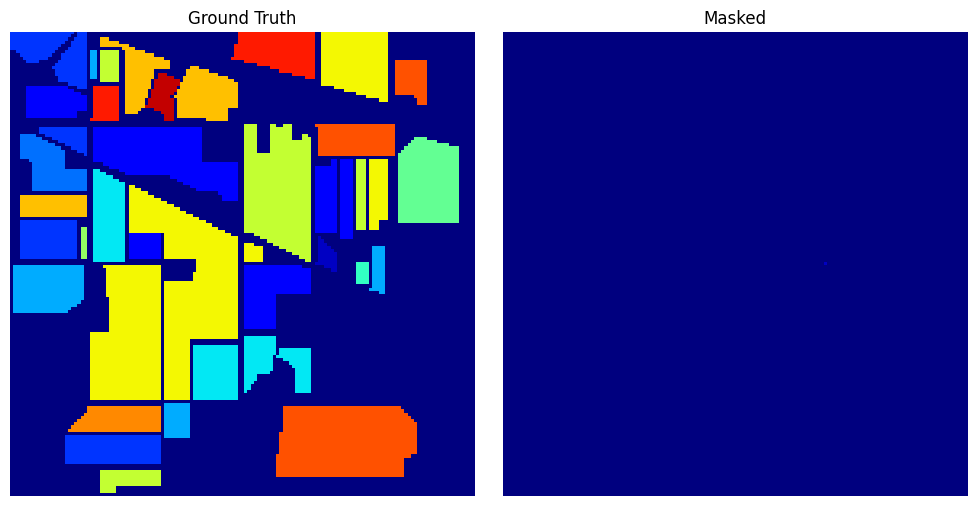

In [16]:
mask = read_fixed_labels_mask(
    f"indian-pines-train-test-split-{target_class}-{data_point_count}.npy",
    folder=RAW_DATA_FOLDER / "mask" / "train-test-split",
)

x_train, y_train, _, _ = pu_bin_train_test_split_by_mask(target_class, x, y, mask)


_ = plot_masked_segmentation_comparison(y.reshape(image_h, image_w), mask)

In [17]:
y_train_unique = unique_counts(y_train)
labeled_datapoints_count = y_train_unique[1]

y_train_unique

{-1: 21024, 1: 1}

In [18]:
y_target = y == target_class

In [19]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y_target, dtype=torch.long)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [20]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [21]:
train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
full_dataset = data.TensorDataset(x_tensor, y_tensor)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=cpu_count,
    persistent_workers=True,
)
full_loader = data.DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [ ]:
positive_count = (y == target_class).sum()
all_count = len(y)
positive_prob = torch.tensor(positive_count / all_count, dtype=torch.float32)

In [23]:
print(f"{target_class} count: {positive_count}")
print(f"Overall count: {all_count}")
print(f"Class prob: {positive_prob}")

1 count: 46
Overall count: 21025
Class prob: 0.1


In [24]:
def extract_prediction(y_hat):
    return (torch.sigmoid(y_hat) > 0.5).to(dtype=torch.int)

In [25]:
pu_loss = PuLoss(
    prior=positive_prob,
    nnpu=True,
    loss_fn=squared_loss,
    gamma=pu_loss_gamma
)

In [26]:
encoder = DBDA(
    band=target_dim,
    classes=latent_space_size,
)

In [27]:
decoder = ViTHsiDecoder(
    latent_dim=latent_space_size,
    out_h=patch_size,
    out_w=patch_size,
    out_bands=target_dim,
    embed_dim=decoder_embed_dim,
    n_layers=decoder_layers,
    n_heads=decoder_heads,
    mlp_dim=decoder_mlp_dim,
)

In [28]:
cls_head = SimpleBinClassificationHead(latent_space_size)

In [29]:
model = AdamOptimizedModule(
    net=AutoEncoderWithClassificationHead(encoder, decoder, cls_head),
    lr=learning_rate,
    weight_decay=weight_decay,
    # scheduler=lambda optimizer: CosineLRSchedulerWrapper(
    #     optimizer,
    #     t_initial=num_epochs,
    #     lr_min=learning_rate * 0.01,
    #     warmup_t=int(np.ceil(0.1 * num_epochs)),
    #     warmup_lr_init=learning_rate * 0.01,
    # ),
)

In [30]:
trainer = MaskedAutoEncoderWithClasificationTrainer(
    loss_fun=MaskedAutoencoderWithClassificationHeadLoss(
        autoencoder_loss=MaskedAutoencoderLoss(alpha=loss_alpha, beta=loss_beta),
        cls_loss=pu_loss,
        cls_loss_weight=cls_loss_weight,
    ),
    num_classes=2,
    epochs=num_epochs,
    masking=HsiPatchMasking(
        mask_ratio=mask_ratio, mode=mask_mode, fill_value=fil_value
    ),
    device=device,
    extract_prediction=extract_prediction,
    model_storage=SimpleFileBackedModelStorage("eval_kappa", f"indian_pines_bin_mae_pu_{target_class}_{labeled_datapoints_count}"),
)

In [31]:
feedback, best_model = trainer.fit(
    model,
    train_loader,
    full_loader,
)

  0%|          | 0/30 [00:00<?, ?it/s]

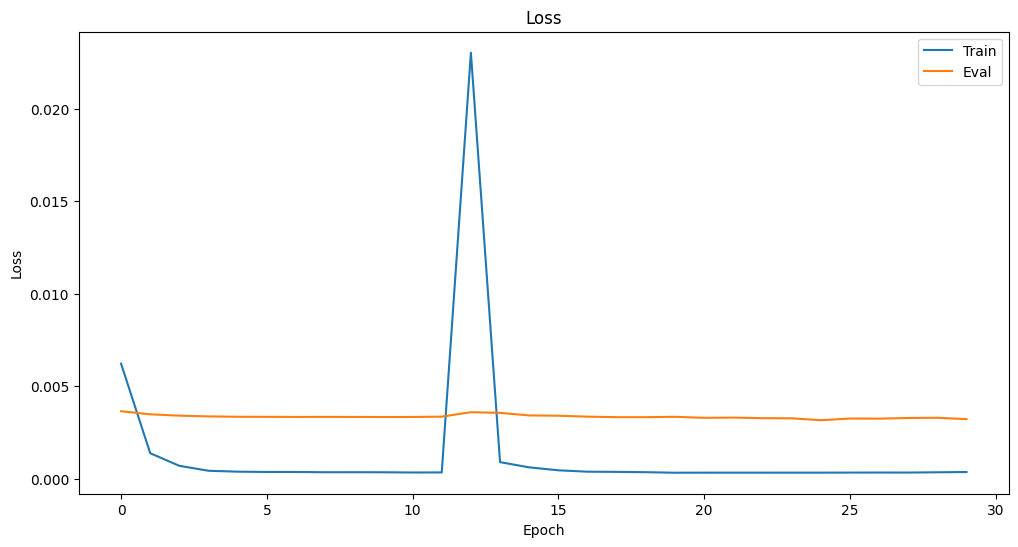

In [32]:
smothed_train = smooth_moving_average(
    [it.train["train_cls_loss"] for it in feedback.history], 1
)
smothed_eval = smooth_moving_average(
    [it.eval["eval_loss"] for it in feedback.history], 1
)

plot_epoch_generic_comparison(smothed_train, smothed_eval)

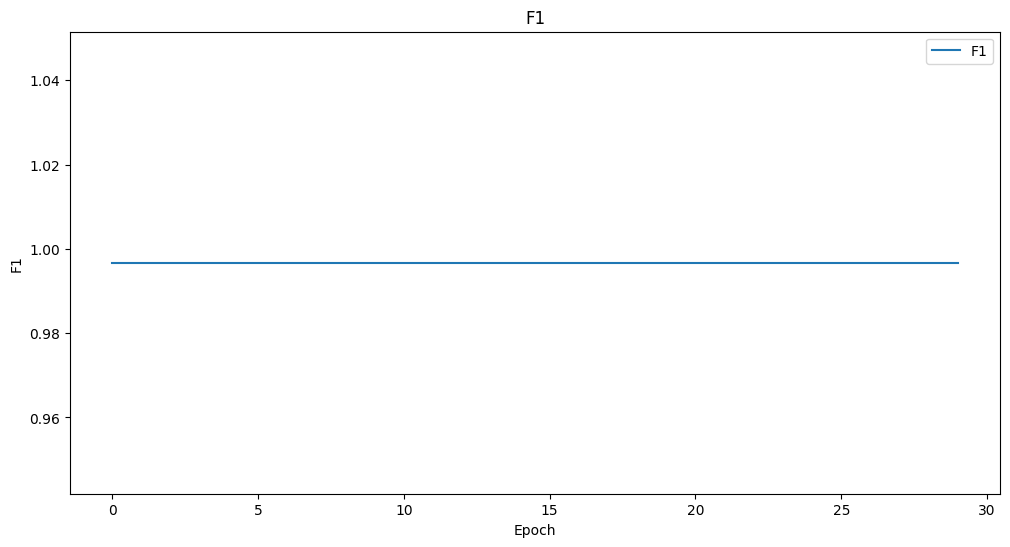

In [33]:
smooth_f1 = smooth_moving_average([it.eval["eval_f1"] for it in feedback.history], 1)

plot_epoch_generic(smooth_f1, desc="F1")

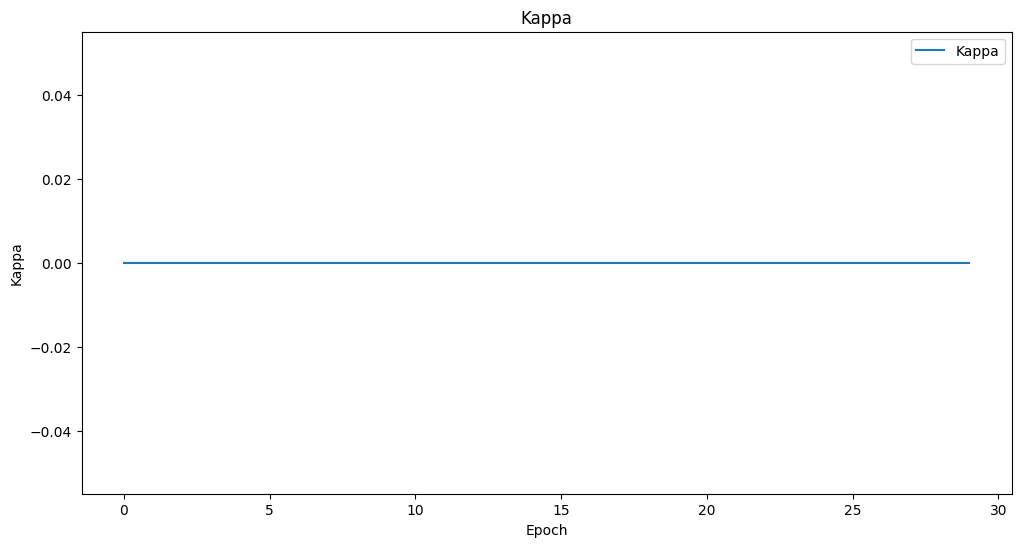

In [34]:
smooth_f1 = smooth_moving_average([it.eval["eval_kappa"] for it in feedback.history], 1)

plot_epoch_generic(smooth_f1, desc="Kappa")

In [35]:
validation_result = trainer.validate(best_model, full_loader)

validation_result

{'eval_f1': 0.9967194199562073,
 'eval_accuracy_overall': 0.5,
 'eval_accuracy_avg': 0.9978121519088745,
 'eval_kappa': 0.0,
 'eval_loss': 0.0036440885719194963}

2. Display prediction

In [36]:
_, y_pred = trainer.predict(best_model, predict_loader)

In [37]:
y_pred = torch.cat(y_pred, dim=0)
y_pred = extract_prediction(y_pred)
y_pred = y_pred.reshape(image_h, image_w)
y_pred = y_pred.cpu()

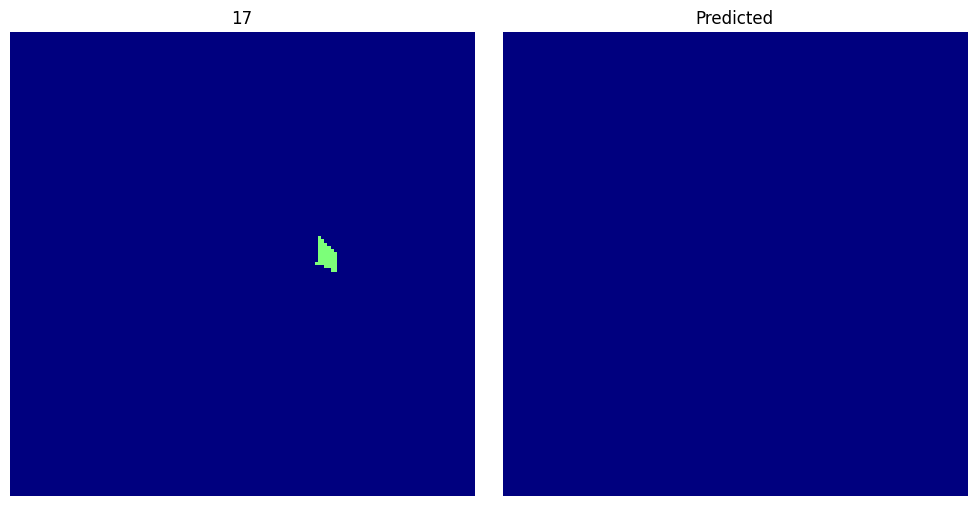

In [38]:
plot_segmentation_comparison(y_target.reshape(image_h, image_w), y_pred.numpy(), num_classes)

6. Write report

In [39]:
model_name = create_model_name(
    "indian_pines_", {target_class: labeled_datapoints_count}
)
model_category = "mae-pu-dbda"

In [40]:
run_params = {
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "patch_size": patch_size,
    "target_dim": target_dim,
    "pre_process_type": str(pre_process_type),
    "dim_reduction_type": str(dim_reduction_type),
    "loss_alpha": loss_alpha,
    "loss_beta": loss_beta,
    "mask_ratio": mask_ratio,
    "mask_mode": mask_mode,
    "fil_value": fil_value,
    "embedding_size": latent_space_size,
    "pre_process_type": str(pre_process_type),
    "dim_reduction_type": str(dim_reduction_type),
    "cls_loss_weight": cls_loss_weight,
    "decoder_layers": decoder_layers,
    "decoder_embed_dim": decoder_embed_dim,
    "decoder_heads": decoder_heads,
    "decoder_mlp_dim": decoder_mlp_dim,
    "pu_loss_gamma": pu_loss_gamma,
}

report_run(
    model_name=model_name,
    model_category=model_category,
    run_desc=run_desc,
    run_params=run_params | model.get_params(),
    run_metrics=classification_trainer(validation_result),
)

PosixPath('/home/melal/Workspace/hsi-classification-playground/reports/runs/indian_pines__1-1.csv')

In [41]:
read_report_to_show(model_name, sort_by_metric="f1")

,timestamp,model_category,run_desc,params,loss,f1,OA,AA,kappa
0,2025-08-17T16:41:00.921110+00:00,mae-pu-dbda,Default run,"{""num_epochs"": 120, ""batch_size"": 24, ""patch_s...",0.000040,0.996719,0.5,0.997812,0.0
1,2025-08-17T17:07:41.357049+00:00,mae-pu-dbda,Default run,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",0.000080,0.996719,0.5,0.997812,0.0
2,2025-08-17T17:39:26.132140+00:00,mae-pu-dbda,Lesser gamma,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",0.000079,0.996719,0.5,0.997812,0.0
3,2025-08-17T18:02:23.639442+00:00,mae-pu-dbda,Bigger gamma,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",0.000080,0.996719,0.5,0.997812,0.0
4,2025-08-17T18:17:42.312257+00:00,mae-pu-dbda,Fixed prior,"{""num_epochs"": 30, ""batch_size"": 64, ""patch_si...",0.003644,0.996719,0.5,0.997812,0.0


In [42]:
read_report_to_show(model_name, sort_by_metric="f1", model_category=model_category)

,timestamp,run_desc,params,loss,f1,OA,AA,kappa
0,2025-08-17T16:41:00.921110+00:00,Default run,"{""num_epochs"": 120, ""batch_size"": 24, ""patch_s...",0.000040,0.996719,0.5,0.997812,0.0
1,2025-08-17T17:07:41.357049+00:00,Default run,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",0.000080,0.996719,0.5,0.997812,0.0
2,2025-08-17T17:39:26.132140+00:00,Lesser gamma,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",0.000079,0.996719,0.5,0.997812,0.0
3,2025-08-17T18:02:23.639442+00:00,Bigger gamma,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",0.000080,0.996719,0.5,0.997812,0.0
4,2025-08-17T18:17:42.312257+00:00,Fixed prior,"{""num_epochs"": 30, ""batch_size"": 64, ""patch_si...",0.003644,0.996719,0.5,0.997812,0.0
